数据集shape： (116, 2)
全部列名： ['label', 'text']
====类别分布====
label
ham     98
spam    18
Name: count, dtype: int64
====文本长度统计信息====
count    116.000000
mean      87.344828
std       54.727484
min       14.000000
25%       41.750000
50%       75.500000
75%      138.000000
max      289.000000
Name: text_len, dtype: float64
====每列空值数量====
label       0
text        0
text_len    0
dtype: int64
完全重复样本数： 1

====类别：ham 随机5条====
- Anything lor... U decide...
- Ok lar i double check wif da hair dresser already he said wun cut v short. He said will cut until i look nice.
- I see the letter B on my car
- Wa, ur openin sentence very formal... Anyway, i'm fine too, juz tt i'm eatin too much n puttin on weight...Haha... So anythin special happened?
- I'm really not up to it still tonight babe

====类别：spam 随机5条====
- Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
- As a valued customer, I am please

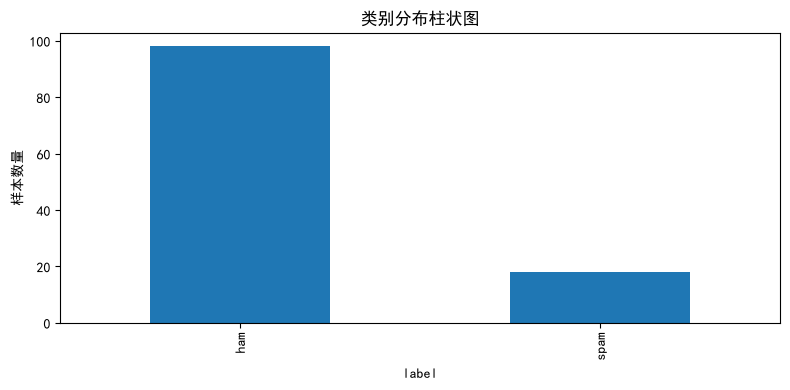

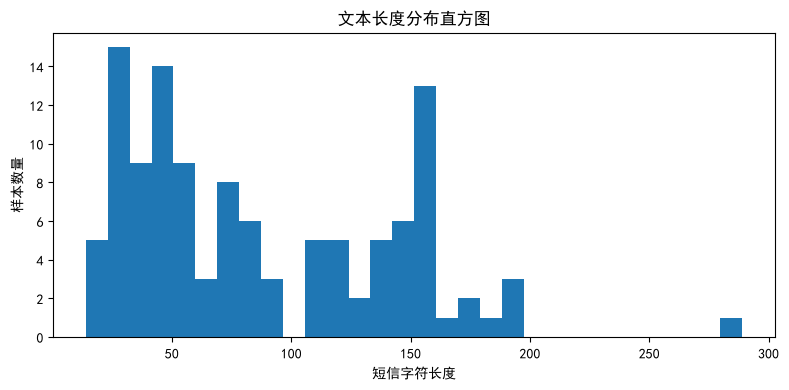

向量：
 [1 3 5]
向量shape = (3,)
含义：一维向量，共有3个元素

矩阵：
 [[10 20]
 [30 40]
 [50 60]]
矩阵shape = (3, 2)
含义：3行2列矩阵，3个样本，每个样本2维特征
====自动数据质量检查====
总样本数：116
空值统计：
label       0
text        0
text_len    0
dtype: int64
完全重复样本数量：1
⚠️存在重复样本，需要注意


In [5]:
# %% [markdown]
# # Week03 数据分析实验
# 数据集：sms_data.csv 短信垃圾邮件分类

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# %%
# 1.读取短信数据集
df = pd.read_csv("sms_data.csv", quoting=1, escapechar='\\')
print("数据集shape：", df.shape)
print("全部列名：", df.columns.tolist())
df.head()

# %%
# 2.类别统计 ham正常短信 / spam垃圾短信
print("====类别分布====")
print(df["label"].value_counts())

# %%
# 3.计算每条短信文本长度
df["text_len"] = df["text"].astype(str).apply(len)
print("====文本长度统计信息====")
print(df["text_len"].describe())

# %%
# 4.空值、重复样本检查
print("====每列空值数量====")
print(df.isna().sum())
print("完全重复样本数：", df.duplicated().sum())

# %%
# 5.每个类别随机看5条原始样本
for lab in df["label"].unique():
    print(f"\n====类别：{lab} 随机5条====")
    samples = df[df["label"] == lab]["text"].sample(5).tolist()
    for s in samples:
        print("-", s)

# %%
# 6.最长5条，最短5条短信
top5_long = df.nlargest(5, "text_len")["text"].tolist()
top5_short = df.nsmallest(5, "text_len")["text"].tolist()
print("====最长5条文本====")
for t in top5_long:
    print(t)
print("\n====最短5条文本====")
for t in top5_short:
    print(t)

# %%
# 7.绘图1：类别分布柱状图，保存图片class_dist.png
plt.figure(figsize=(8,4))
df["label"].value_counts().plot(kind="bar")
plt.title("类别分布柱状图")
plt.ylabel("样本数量")
plt.tight_layout()
plt.savefig("class_dist.png")
plt.show()

# %%
# 8.绘图2：文本长度直方图，保存图片text_len_hist.png
plt.figure(figsize=(8,4))
plt.hist(df["text_len"], bins=30)
plt.title("文本长度分布直方图")
plt.xlabel("短信字符长度")
plt.ylabel("样本数量")
plt.tight_layout()
plt.savefig("text_len_hist.png")
plt.show()

# %%
# 9.Numpy向量、矩阵练习
vec = np.array([1, 3, 5])
mat = np.array([[10,20],
                [30,40],
                [50,60]])
print("向量：\n", vec)
print("向量shape =", vec.shape)
print("含义：一维向量，共有3个元素")

print("\n矩阵：\n", mat)
print("矩阵shape =", mat.shape)
print("含义：3行2列矩阵，3个样本，每个样本2维特征")

# %%
# 拓展任务：check_data 自动数据检查函数
def check_data(df):
    print("====自动数据质量检查====")
    print(f"总样本数：{df.shape[0]}")
    print(f"空值统计：\n{df.isna().sum()}")
    dup_total = df.duplicated().sum()
    print(f"完全重复样本数量：{dup_total}")
    if dup_total>0:
        print("⚠️存在重复样本，需要注意")
check_data(df)
